# Blockies Dataset

This notebook download the blockies dataset and the corresponding trained model.  This is then used to evaluate the model on all datasets.  

Additionally, we provide a review of the various Blocky traits, to review the distributions between ill and healthy Blockies.

In [1]:
import os
from pathlib import Path
import tarfile
import random

import zipfile

import numpy as np

import pandas as pd

from sklearn.metrics import r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms as T

from PIL import Image

import matplotlib.pyplot as plt

torch.backends.cudnn.benchmark = True

In [228]:
CLASSES = ['Healthy', 'OCDegen']

modeltype = 'resnet18_regression'

regression_target_columns = [
    'main_spherical', 'sec_spherical', 'bending',  'arm_position',
    'num_sec_bones', 'obj_rotation_roll', 'obj_rotation_pitch', 'obj_rotation_yaw',
    'position_x', 'position_y',
    'obj_color', 'bg_color',
    ]

ds = 'main_blockies/default'
eval_ds = 'main_blockies/highvar'

random_state = 42

output_folder = Path('output/xai_samples/concept_based')
(output_folder / 'tmp').mkdir(parents=True, exist_ok=True)
(output_folder / 'main_data').mkdir(parents=True, exist_ok=True)
(output_folder / 'tutorial_data').mkdir(parents=True, exist_ok=True)

In [3]:
readable_names = ['Main Bone Shape', 'Sec. Bone Shape', 'Spine Bend', 'Arm Position',
                  'Num. Sec. Bones', 'Position - Roll', 'Position - Pitch', 'Position - Yaw',
                  'Position - X', 'Position-Y', 'Blocky Color', 'Background Color']
name_map = {col: n for col, n in zip(regression_target_columns, readable_names)}
name_map_pred = {f'{col}_pred': n for col, n in zip(regression_target_columns, readable_names)}

# Setup and Load Datasets

In [4]:
# data downloading and dataset utilities
def download_file(url, file_name, cache_dir="data", extract=True, force_download=False, archive_folder=None):
    # Ensure the cache directory exists
    os.makedirs(cache_dir, exist_ok=True)
    file_path = os.path.join(cache_dir, file_name)

    # Download the file
    if not os.path.exists(file_path) or force_download:
      torch.hub.download_url_to_file(url, file_path)
      print(f"File downloaded to: {file_path}")
    else:
      print(f"File already exists at: {file_path}")

    if extract:
      if file_path.endswith(".tar.gz"):
        print("Extracting tar.gz file...")
        with tarfile.open(file_path, "r:gz") as tar:
            tar.extractall(path=cache_dir)
      elif file_path.endswith(".zip"):
        print("Extracting zip file...")
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(cache_dir)
      else:
        raise ValueError("Unsupported file format. Only .tar.gz and .zip files are supported.")

      print(f"File extracted to: {cache_dir}")
      return Path(cache_dir) / archive_folder if archive_folder is not None else Path(cache_dir)

    return Path(file_path)

In [5]:
def load_dataframe(data_dir, dataset):
  data_dir = data_dir / dataset
  df = pd.read_json(data_dir / 'parameters.jsonl', lines=True, dtype={'sec_bones': str})
  df['filename'] = df['id'] + '.png'
  df['ill'] = (df['obj_name'] == 'ocd').astype(int)
  df['sphere_diff'] = (df.main_spherical - df.sec_spherical).abs()
  df['num_sec_bones'] = df.sec_bones.apply(lambda x: x.count('1'))

  return df

In [6]:
class ImageRegressionDataset(Dataset):
    def __init__(self, df, data_dir, transform=None, target_columns=None):
        self.df = df
        self.data_dir = data_dir
        self.transform = transform
        self.target_columns = target_columns if target_columns is not None else ['main_spherical', 'sec_spherical', 'bending', 'arm_position']


    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_path).convert('RGB')
        # Load the specified target columns instead of just 'ill'
        targets = self.df.iloc[idx][self.target_columns].values.astype(np.float32)
        targets = torch.tensor(targets)

        if self.transform:
            image = self.transform(image)

        return image, targets

## Load Dataset and Dataloaders


In [7]:
import ast
def convert_string_list_to_list(df, column_name):
    df[column_name] = df[column_name].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    return df

In [8]:
# download data direcly from sciebo

data_zip = 'https://uni-bielefeld.sciebo.de/s/MlRrDyzD0GKOK67/download'
zip_name = 'study_samples'

data_dir = download_file(url=data_zip,
                          file_name=f"{zip_name}.zip",
                          cache_dir='data', # change this if not using Colab
                          extract=True,
                          force_download=False,
                          archive_folder=zip_name)
data_dir

File already exists at: data/study_samples.zip
Extracting zip file...
File extracted to: data


PosixPath('data/study_samples')

In [9]:
# load and preprocess dataframes
main_dir = data_dir / 'main_data/xai_samples'
tutorial_dir = data_dir / 'tutorial_data/xai_samples'

study_df = pd.read_csv(main_dir / 'xai_samples_df.csv')
study_df = convert_string_list_to_list(study_df, 'ill_chars')
study_df['ill_label'] = study_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
study_df['pred_label'] = study_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})

tutorial_df = pd.read_csv(tutorial_dir / 'xai_samples_df.csv')
tutorial_df = convert_string_list_to_list(tutorial_df, 'ill_chars')
tutorial_df['ill_label'] = tutorial_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
tutorial_df['pred_label'] = tutorial_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})


In [10]:
# blockies v2 - 2 class dataset
mean = [0.8258, 0.8043, 0.8164]
std = [0.0768, 0.0835, 0.0904]


transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=mean, std=std)
])

num_workers = 0

study_dataset = ImageRegressionDataset(study_df, main_dir, 
                                       transform=transform, target_columns=regression_target_columns)
study_dataloader = DataLoader(study_dataset, batch_size=1, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

tutorial_dataset = ImageRegressionDataset(tutorial_df, tutorial_dir,
                                           transform=transform, target_columns=regression_target_columns)
tutorial_dataloader = DataLoader(tutorial_dataset, batch_size=1, shuffle=False,
                                 num_workers=num_workers, pin_memory=True)

In [11]:
# load test data from examples
# download data direcly from sciebo
# (or setup own data location if prefered)
full_data_dir = download_file(url="https://uni-bielefeld.sciebo.de/s/yfEHoeqfJq4rK7R/download",
                         file_name="blockies_datasets.tar.gz",
                         cache_dir='data', # change this if not using Colab
                         extract=True,
                         force_download=False,
                         archive_folder='blockies_datasets')


File already exists at: data/blockies_datasets.tar.gz
Extracting tar.gz file...
File extracted to: data


In [12]:
ds_dir = full_data_dir / ds
print(ds_dir)
test_df = load_dataframe(ds_dir, 'test')

data/blockies_datasets/main_blockies/default


In [13]:
test_dataset = ImageRegressionDataset(test_df, ds_dir / 'test',
                                      transform=transform, target_columns=regression_target_columns)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

# Model Loading and Evaluation





In [14]:
def load_resnet18(num_classes, pretrained=True, checkpoint_path=None):
  model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
  model.fc = nn.Linear(model.fc.in_features, num_classes)
  print("Loaded random model")

  if checkpoint_path:
      checkpoint = torch.load(checkpoint_path, map_location='cpu')
      model.load_state_dict(checkpoint)
      print(f"Loaded checkpoint from: {checkpoint_path}")

  return model

def load_resnet18_regression(num_targets, pretrained=True, checkpoint_path=None):
  model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
  model.fc = nn.Linear(model.fc.in_features, num_targets)
  print("Loaded ResNet18")

  if checkpoint_path:
      checkpoint = torch.load(checkpoint_path, map_location='cpu')
      model.load_state_dict(checkpoint)
      print(f"Loaded checkpoint from: {checkpoint_path}")

  return model

In [15]:
def set_seed(seed):
  """
  Sets random seeds for reproducibility.
  """
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False


def evaluate_model(model, dataloader, criterion, device, num_targets):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0

    all_preds = []
    all_labels = []


    with torch.no_grad():  # Disable gradient calculation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item()
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(dataloader)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate R-squared for each target
    r2_scores = []
    for i in range(num_targets):
        r2 = r2_score(all_labels[:, i], all_preds[:, i])
        r2_scores.append(r2)

    print(f"Evaluation Loss: {avg_loss:.4f}")
    for i, r2 in enumerate(r2_scores):
        print(f"R-squared for target {i}: {r2:.4f}")
    return all_preds, avg_loss, r2_scores

In [16]:
checkpoint_path = download_file(url='https://uni-bielefeld.sciebo.de/s/qpOuSHKCgN31OCO/download',
                                file_name='best_model.pth',
                                cache_dir=f'checkpoint/{modeltype}_checkpoint', # change this if not using Colab
                                extract=False,
                                force_download=True)
checkpoint_path

  0%|          | 0.00/42.7M [00:00<?, ?B/s]

File downloaded to: checkpoint/resnet18_regression_checkpoint/best_model.pth


PosixPath('checkpoint/resnet18_regression_checkpoint/best_model.pth')

In [17]:
# Define loss function and optimizer
criterion = nn.MSELoss(reduction='sum')

n_targets = len(regression_target_columns)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Evaluate Model

In [18]:
# load best model and evaluate
model = load_resnet18_regression(n_targets,
                                 pretrained=False,
                                 checkpoint_path=checkpoint_path)
model.to(device)

study_preds, _, _ = evaluate_model(model, study_dataloader, criterion, device, n_targets)
tutorial_preds, _, _ = evaluate_model(model, tutorial_dataloader, criterion, device, n_targets)

Loaded ResNet18
Loaded checkpoint from: checkpoint/resnet18_regression_checkpoint/best_model.pth
Evaluation Loss: 0.3791
R-squared for target 0: 0.9694
R-squared for target 1: 0.8239
R-squared for target 2: 0.7605
R-squared for target 3: 0.5902
R-squared for target 4: 0.7804
R-squared for target 5: 0.1163
R-squared for target 6: 0.9574
R-squared for target 7: 0.9829
R-squared for target 8: 0.7302
R-squared for target 9: 0.8703
R-squared for target 10: 0.9915
R-squared for target 11: 0.9984
Evaluation Loss: 0.0057
R-squared for target 0: 0.9988
R-squared for target 1: 0.9737
R-squared for target 2: 0.9915
R-squared for target 3: 0.9616
R-squared for target 4: 0.9967
R-squared for target 5: -0.1399
R-squared for target 6: 0.9965
R-squared for target 7: 0.9998
R-squared for target 8: 0.9929
R-squared for target 9: 0.9901
R-squared for target 10: 0.9978
R-squared for target 11: 0.9994


In [19]:
# add concept preds to dataframe
study_preds_df = pd.DataFrame(study_preds, columns=regression_target_columns)
tutorial_preds_df = pd.DataFrame(tutorial_preds, columns=regression_target_columns)

new_cols = [f'{f}_pred' for f in regression_target_columns]

### Load the Interpretable Model

In [20]:
import joblib

In [21]:
ebm_model = download_file(url='https://uni-bielefeld.sciebo.de/s/elbFZKs3PlzVxGK/download',
                          file_name='ebm_model.joblib',
                          cache_dir=f'checkpoint/interpretable', # change this if not using Colab
                          extract=False,
                          force_download=True)
ebm_model

  0%|          | 0.00/20.8M [00:00<?, ?B/s]

File downloaded to: checkpoint/interpretable/ebm_model.joblib


PosixPath('checkpoint/interpretable/ebm_model.joblib')

In [22]:
ebm = joblib.load(ebm_model)

In [23]:
X_study = study_df[new_cols].copy()
X_study = X_study.rename(columns=name_map_pred)

X_tutorial = tutorial_df[new_cols].copy()
X_tutorial = X_tutorial.rename(columns=name_map_pred)

In [24]:
study_preds = ebm.predict(X_study)
tutorial_preds = ebm.predict(X_tutorial)

ebm.score(X_study, study_df['ill']), ebm.score(X_tutorial, tutorial_df['ill'])

(0.8, 0.6)

In [25]:
# assert that all predictions are the same
assert (study_preds == study_df['pred']).all(), 'Study predictions are incorrect'
assert (tutorial_preds == tutorial_df['pred']).all(), 'Tutorial predictions are incorrect '

print('All predictions for each dataset are equal. This is the correct model')

All predictions for each dataset are equal. This is the correct model


## View the XAI Dataset

In [26]:
test = np.array([np.array(Image.open(p).convert('RGB')) for p in main_dir / study_df['filename']])

In [27]:
def display_images(df, n_rows, n_cols, img_dir, title, random_state=0):
  """ Function to display images in a grid randomly selected from a dataframe of images.

  Args:
    df (pd.DataFrame): dataframe of images
    n_rows (int): number of rows in the grid
    n_cols (int): number of columns in the grid
    title (str): title of the plot
    random_state (int): random state for reproducibility
  """

  if n_rows == 0 and n_cols == 0:
    print(f'Not data to display for Figure - {title}')
    return

  if n_rows * n_cols < len(df):
    df = df.sample(n_rows * n_cols, random_state=random_state)

  figsize = (n_cols * 2, n_rows*2.5)
  print(figsize)

  test_images = np.array([np.array(Image.open(p).convert('RGB')) for p in img_dir / df['filename']]) * 1. / 255
  fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
  axes = np.array(axes)
  for i, (ax, idx) in enumerate(zip(axes.flat, df.index)):
    ax.imshow(test_images[i])
    ax.set_title(f'True={df.loc[idx]["ill"]} - Pred={df.loc[idx]["pred"]}')
    ax.axis('off')

  fig.suptitle(title)
  fig.tight_layout()

(16, 12.5)


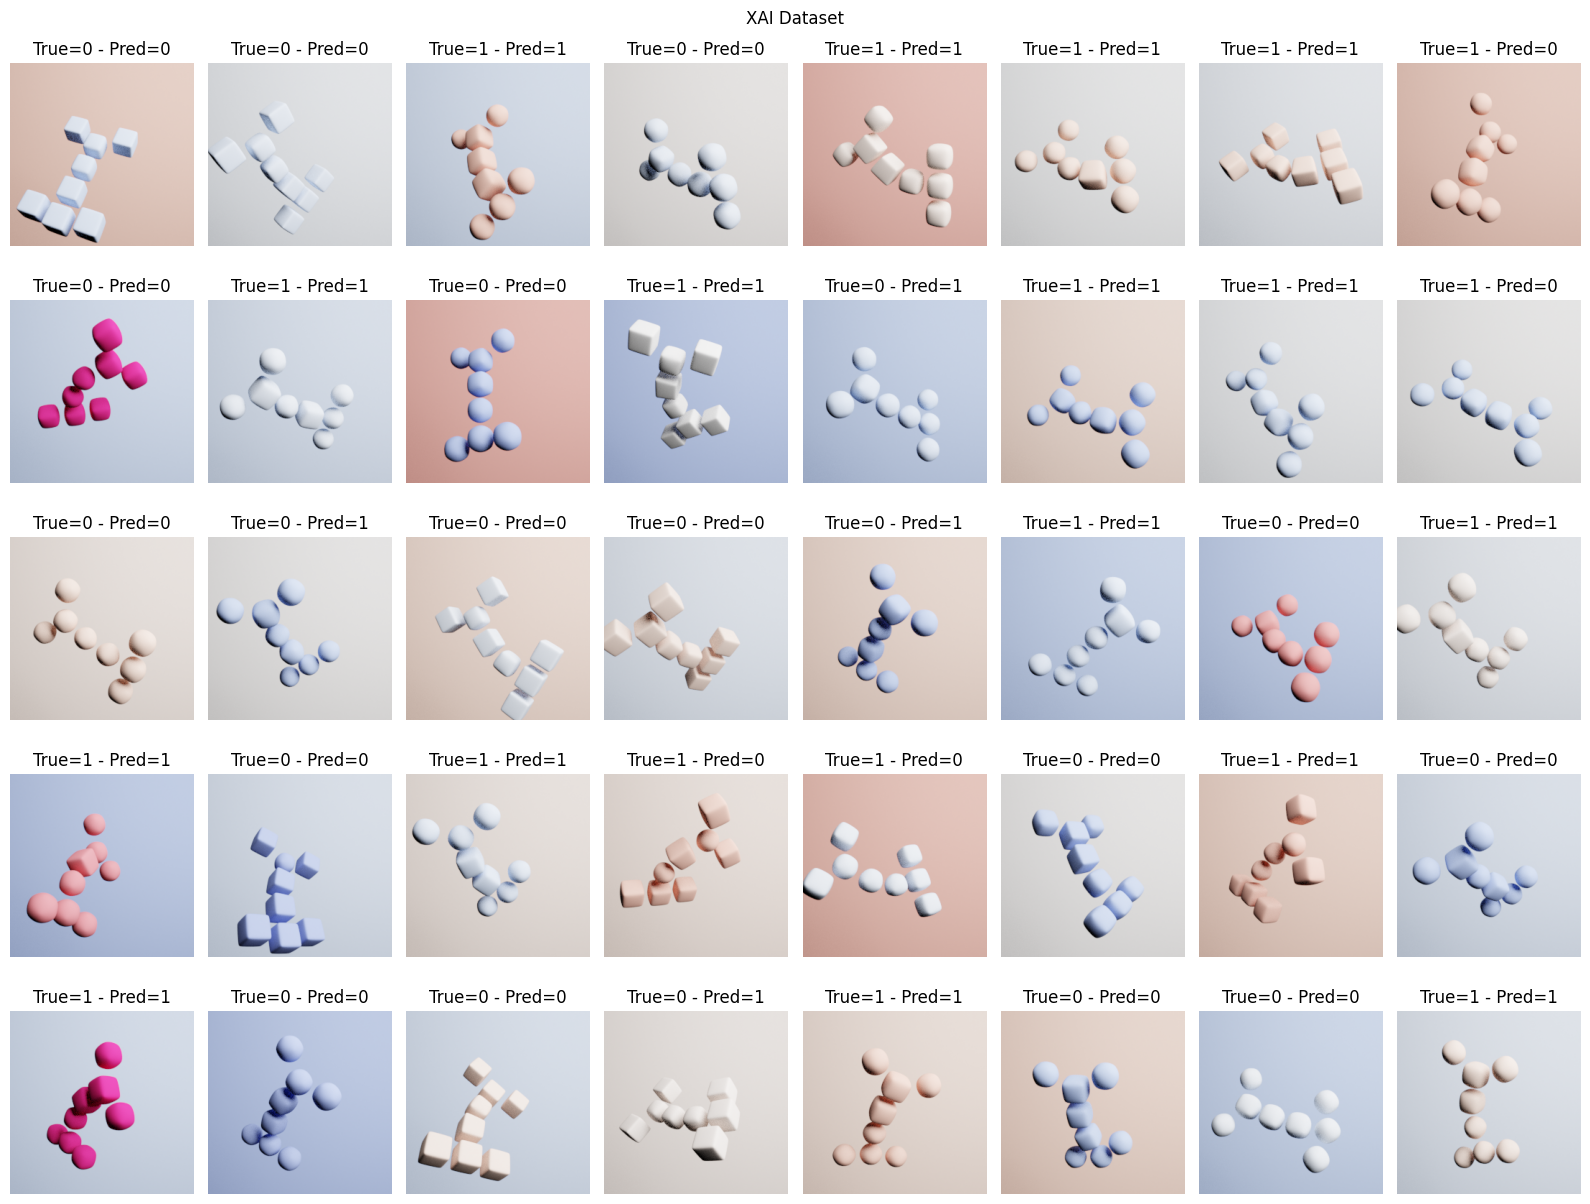

In [28]:
display_images(study_df, 5, 8, main_dir, f'XAI Dataset', random_state=0)

## Generate Explanations

In [29]:
from interpret import show

from zennit.rules import Epsilon
from zennit.image import imgify

from zennit.attribution import Gradient
from zennit.torchvision import ResNetCanonizer
from zennit.canonizers import SequentialMergeBatchNorm
from zennit.composites import EpsilonPlusFlat, EpsilonGammaBox, EpsilonAlpha2Beta1Flat, EpsilonAlpha2Beta1

In [30]:
exp = ebm.explain_local(X_study, study_df['ill'])

In [39]:
import matplotlib as mpl

def combine_and_save(img, attribution, alpha, filter_perc, filename):

    relevance = attribution.sum(0)

    mask_neg = relevance < 0
    neg_rel = abs(relevance) * mask_neg
    thresh_neg = torch.quantile(neg_rel.flatten(), filter_perc)
    mask_neg = neg_rel > thresh_neg

    mask_pos = relevance > 0
    pos_rel = relevance * mask_pos
    thresh_pos = torch.quantile(pos_rel.flatten(), filter_perc)
    mask_pos = pos_rel > thresh_pos

    relevance = relevance * (mask_neg | mask_pos)

    vmax = relevance.abs().max()
    grayscale_img = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])

    cmap = plt.get_cmap('seismic')
    norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax, clip=False)
    heatmap_colored = cmap(norm(relevance))[:, :, :3] # Take only RGB channels

    # Convert grayscale image to RGB
    grayscale_rgb = np.stack([grayscale_img] * 3, axis=-1)

    # Combine the grayscale image and the colored heatmap
    # You can adjust the alpha value for the heatmap overlay
    combined_img_np = (grayscale_rgb * (1 - alpha) + heatmap_colored * 255 * alpha).astype(np.uint8)

    # Convert to PIL Image and save
    combined_img_pil = Image.fromarray(combined_img_np)
    combined_img_pil.save(filename)

    return combined_img_pil

In [204]:
def multihot_encode(labels, num_classes):
  """
    Generates a multi-hot encoded tensor from a tuple of labels.

    Args:
        labels (tuple): A tuple of integer labels.
        num_classes (int): The total number of possible classes.

    Returns:
        torch.Tensor: A multi-hot encoded tensor of shape (num_classes,).
    """
  one_hot = torch.zeros(num_classes)
  for label in labels:
    one_hot[label] = 1
  return one_hot

def process_names(name):
  name = name.split(' & ') if '&' in name else [str(name)]
  return name

def calc_and_save_lrp(sample, names, img_dir):

    path = img_dir / sample['filename'].values[0]
    img = Image.open(path).convert('RGB')

    feature_idxs = [tuple(readable_names.index(n) for n in process_names(ns)) for ns in names]

    targets = []
    imgs = []
    for idxs in feature_idxs:
        t = multihot_encode(idxs, len(new_cols))
        targets.append(t)
        imgs.append(img)
    targets = torch.stack(targets)

    inp = [transform(img) for img in imgs]
    inp = torch.stack(inp)
    imgs_np = np.array([np.array(img) for img in imgs])

    with Gradient(model=model, composite=EpsilonAlpha2Beta1Flat(canonizers=[ResNetCanonizer()])) as attributor:
      inp = inp.to('cpu')
      output, attribution = attributor(inp, targets)

    filenames  = []
    for i, hm in enumerate(attribution):
        filename = f'{sample["id"].values[0]}_lrp_{i}.png'
        path = output_folder / 'tmp' / filename
        img = combine_and_save(imgs_np[i], hm, alpha=.85, filter_perc=.90, filename=path)
        filenames.append(filename)

    return filenames

In [207]:

def get_top_concepts(sample, feature_cols, target_col, img_dir, n_concepts=3):
    # Get the top concepts from the model

    assert len(sample) == 1, 'Function only handles a single instance'

    exp = ebm.explain_local(sample[feature_cols], sample[target_col])
    sorted_indices = np.argsort(abs(np.array(exp.data(0)['scores'])))
    sorted_indices = sorted_indices[::-1]
    scores = np.array(exp.data(0)['scores'])[sorted_indices]
    names = np.array(exp.data(0)['names'])[sorted_indices]

    values = []
    for n in names[:n_concepts]:
        n = n.split(' & ') if '&' in n else [n]
        n = [s.strip() for s in n]
        v = tuple(sample[s].values[0] for s in n)
        values.append(v)

    # calculate lrp for the top concepts
    filenames = calc_and_save_lrp(sample, names[:n_concepts], img_dir, )
    # generate df (cols: lrp filenames, concept names, concept values)
    df = pd.DataFrame({
        'concept': names[:n_concepts],
        'score': scores[:n_concepts],
        'filename': filenames,
        'values': values
    })

    return df

In [208]:
study_df_copy = study_df.copy().rename(columns=name_map_pred)
sample = study_df_copy.iloc[0:1]
concepts = get_top_concepts(sample, name_map_pred.values(), 'ill', main_dir, n_concepts=4)

In [209]:
concepts

,concept,score,filename,values
0,Main Bone Shape & Sec. Bone Shape,-6.105904,cec708b5-2af1-454b-a0c8-8c8047565127_lrp_0.png,"(0.048010744, 0.32434145)"
1,Spine Bend & Arm Position,-3.120153,cec708b5-2af1-454b-a0c8-8c8047565127_lrp_1.png,"(0.020773262, 0.34929752)"
2,Main Bone Shape,-2.305217,cec708b5-2af1-454b-a0c8-8c8047565127_lrp_2.png,"(0.048010744,)"
3,Main Bone Shape & Spine Bend,-2.073979,cec708b5-2af1-454b-a0c8-8c8047565127_lrp_3.png,"(0.048010744, 0.020773262)"


In [210]:
get_caption(concepts.iloc[0])

'Low Bone Shape Variation: 0.28<br>Score: 6.11 for Healthy'

In [229]:
# CSV Generation

import random
import ast
import numpy as np
import pandas as pd
import csv

# Class labels
CLASSES = ['Healthy', 'OCDegen']

name_map = {
    'Main Bone Shape': ["Main Bones: Sharp Cuboids", "Main Bones: Rounded Cuboids", "Main Bones: Blocky Spheres", "Main Bones: Smooth Sphere", "Main Bones Mutation"],
    'Sec. Bone Shape': ["Sec. Bones: Sharp Cuboids", "Sec. Bones: Rounded Cuboids", "Sec. Bones: Blocky Spheres", "Sec. Bones: Smooth Sphere", "Sec. Bones Mutation"],
    'Arm Position': ["Extended Head", "Slightly Extended Head", "Slightly Tucked Head", "Tucked Head"],
    'Bone Shape Variation': ["Negligible Bone Shape Variation", "Low Bone Shape Variation", "Medium Bone Shape Variation", "High Bone Shape Variation"],
    'Spine Bend': ["Negligible Spine Bend", "Low Spine Bend", "Medium Spine Bend", "High Spine Bend"],
    'Num. Sec. Bones': ["1 Sec. Bone", "2 Sec. Bones", "3 Sec. Bones", "4 Sec. Bones"],
    'Blocky Color': ["Red Bones", "Reddish-Grey Bones", "Bluish-Grey Bones", "Blue Bones"],
    'Background Color': ["Red Background", "Reddish-Grey Background", "Bluish-Grey Background", "Blue Background"],
    'Position - Roll': ['No Roll', 'Slight Roll', 'Moderate Roll', 'Severe Roll'],
    'Position - Yaw': ['No Yaw', 'Slight Yaw', 'Moderate Yaw', 'Severe Yaw'],
    'Position - Pitch': ['No Pitch', 'Slight Pitch', 'Moderate Pitch', 'Severe Pitch'],
    'Position - X': ['No Horizontal Shift', 'Slight Horizontal Shift', 'Moderate Horizontal Shift', 'Severe Horizontal Shift'],
    'Position - Y': ['No Vertical Shift', 'Slight Vertical Shift', 'Moderate Vertical Shift', 'Severe Vertical Shift'],
    }

ranges = {
    'Main Bone Shape': (0, 1.3),
    'Sec. Bone Shape': (0, 1.3),
    'Arm Position': (0, 1),
    'Bone Shape Variation': (0.1, 0.8),
    'Spine Bend': (0, 0.4),
    'Num. Sec. Bones': (1, 4),
    'Blocky Color': (0, 1),
    'Background Color': (0, 1),
    'Position - Roll': (0, 0.75),
    'Position - Yaw': (0, 0.75),
    'Position - Pitch': (0, 0.75),
    'Position - X': (0, 0.75),
    'Position - Y': (0, 0.75),
}

def discretize_value(value, min_val, max_val, n_bins):
    """
    Discretize a continuous value into one of 4 integer bins (0,1,2,3).

    Parameters:
        value (float): The continuous value to discretize.
        min_val (float): The minimum possible value.
        max_val (float): The maximum possible value.

    Returns:
        int: An integer in [0, 3].
    """
    if max_val == min_val:
        raise ValueError("min_val and max_val must be different")

    # Normalize into [0,1]
    norm = (value - min_val) / (max_val - min_val)
    norm = max(0.0, min(1.0, norm))  # clamp to [0,1]

    # Scale into 4 bins
    return min(n_bins - 1, int(norm * n_bins))


def get_hc_name(concepts, values):
    """
    Returns a two-line caption for Healthy and OCDegen concepts.
    """
    
    if 'Main Bone Shape' in concepts and 'Sec. Bone Shape' in concepts:
        concepts = ['Bone Shape Variation']
        values = [abs(values[0] - values[1])]

    concept_strs = []
    for c, v in zip(concepts, values):
        range = ranges[c]
        n_bins = len(name_map[c])
        int_val = discretize_value(v, range[0], range[1], n_bins)
        concept_strs.append(f'{name_map[c][int_val]}: {v:.2f}')

    return " & ".join(concept_strs)

def get_caption(df_concepts):
    """
    Returns a two-line caption so that CSV viewers
    will show a true line break in the cell.
    """
    concepts = df_concepts["concept"].split(' & ')
    concepts = [c.strip() for c in concepts]

    values = df_concepts["values"]

    concepts_str = get_hc_name(concepts, values)
    
    score = df_concepts["score"]
    score_str = f'Score: {abs(score):.2f} for {"Healthy" if score < 0 else "OCDegen"}'

    return f'{concepts_str}<br>{score_str}'

def get_xray_trait(df, xray_filename):
    matches = df.loc[
        df['filename'] == xray_filename,
        'ill_chars'
    ].values
    if len(matches) == 0:
        return "Unknown"
    ill_raw = matches[0]
    try:
        traits = ast.literal_eval(ill_raw) if isinstance(ill_raw, str) else ill_raw
    except:
        traits = []

    mapped = []
    for trait in traits:
        t = trait.strip()
        if "mutation_color" in t.lower():
            continue
        if t in ["high_bend", "med_bend"] and "Strong Spine Bend" not in mapped:
            mapped.append("Strong Spine Bend")
        elif t in ["high_sphere_diff", "med_sphere_diff"] and "Strong Bone Variation" not in mapped:
            mapped.append("Strong Bone Variation")
        elif t == "mutation_mainbones" and "Main Bones Mutation" not in mapped:
            mapped.append("Main Bones Mutation")
        elif t == "stretchy" and "Tucked Head" not in mapped:
            mapped.append("Tucked Head")
        else:
            mapped.append(t)
    return ", ".join(mapped) if mapped else "No Trait"


# Final schema
final_columns = [
    "INDEX", "PATIENT_ID", "X_RAY_IMAGE", "X_RAY_TRAIT",
    "TRUE_DIAG", "SUGGESTED_DIAG",
    "Example1", "Example1_Caption",
    "Example2", "Example2_Caption",
    "Example3", "Example3_Caption",
    "Example4", "Example4_Caption",
    "X_RAY_LOCATION"
]


In [230]:

# Start with an empty DataFrame
df = pd.DataFrame(columns=final_columns)

n_concepts = 4

# Build one row per X-ray
study_df_copy = study_df.copy().rename(columns=name_map_pred)
for _, row in study_df_copy.iterrows():
    target_true     = int(row['ill'])
    target_pred     = int(row['pred'])
    id_to_drop      = row['id']

    top_concepts = get_top_concepts(row.to_frame().T, name_map_pred.values(), 'ill', main_dir, n_concepts=n_concepts)

    new_row = {
        "PATIENT_ID": row['p_id'],
        "X_RAY_IMAGE": row['filename'],
        "TRUE_DIAG": CLASSES[target_true],
        "SUGGESTED_DIAG": CLASSES[target_pred],
        "Example1": top_concepts['filename'].iloc[0],
        "Example1_Caption": get_caption(top_concepts.iloc[0]),
        "Example2": top_concepts['filename'].iloc[1],
        "Example2_Caption": get_caption(top_concepts.iloc[1]),
        "Example3": top_concepts['filename'].iloc[2],
        "Example3_Caption": get_caption(top_concepts.iloc[2]),
        "Example4": top_concepts['filename'].iloc[3],
        "Example4_Caption": get_caption(top_concepts.iloc[3])
    }
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

# Fill in traits
df['X_RAY_TRAIT'] = df['X_RAY_IMAGE'].apply(lambda x: get_xray_trait(study_df, x))

# Random locations
locations = ["DEN", "SEA", "CHI", "SF", "MIA", "PHX", "BOS", "ATL"]
df["X_RAY_LOCATION"] = random.choices(locations, k=len(df))

# Refresh INDEX
if "INDEX" in df.columns:
    df = df.drop(columns=["INDEX"])
df["INDEX"] = random.sample(range(1, 100 + len(df)), len(df))

# Reorder & save with quoting so newlines persist
df = df[final_columns]
df.to_csv(
    output_folder / "main_data/input_example.csv",
    index=False,
    quoting=csv.QUOTE_ALL
)
print(f"Saved {output_folder / 'main_data/input_example.csv'} with captions")

Saved output/xai_samples/concept_based/main_data/input_example.csv with captions


In [231]:
df

,INDEX,PATIENT_ID,X_RAY_IMAGE,X_RAY_TRAIT,TRUE_DIAG,SUGGESTED_DIAG,Example1,Example1_Caption,Example2,Example2_Caption,Example3,Example3_Caption,Example4,Example4_Caption,X_RAY_LOCATION
0,31,C1VY3F7T,cec708b5-2af1-454b-a0c8-8c8047565127.png,No Trait,Healthy,Healthy,cec708b5-2af1-454b-a0c8-8c8047565127_lrp_0.png,Low Bone Shape Variation: 0.28<br>Score: 6.11 ...,cec708b5-2af1-454b-a0c8-8c8047565127_lrp_1.png,Negligible Spine Bend: 0.02 & Slightly Extende...,cec708b5-2af1-454b-a0c8-8c8047565127_lrp_2.png,Main Bones: Sharp Cuboids: 0.05<br>Score: 2.31...,cec708b5-2af1-454b-a0c8-8c8047565127_lrp_3.png,Main Bones: Sharp Cuboids: 0.05 & Negligible S...,DEN
1,22,D0KGZDN2,33f21483-6240-4fd5-95bc-36be485b3259.png,Tucked Head,Healthy,Healthy,33f21483-6240-4fd5-95bc-36be485b3259_lrp_0.png,Low Bone Shape Variation: 0.35<br>Score: 6.36 ...,33f21483-6240-4fd5-95bc-36be485b3259_lrp_1.png,Low Spine Bend: 0.10 & Slightly Extended Head:...,33f21483-6240-4fd5-95bc-36be485b3259_lrp_2.png,Main Bones: Sharp Cuboids: 0.09<br>Score: 2.28...,33f21483-6240-4fd5-95bc-36be485b3259_lrp_3.png,Main Bones: Sharp Cuboids: 0.09 & Low Spine Be...,PHX
2,105,1LTSPN1Q,b3458f5b-9f17-4186-90ca-57e8bf1bc739.png,"Strong Bone Variation, Main Bones Mutation",OCDegen,OCDegen,b3458f5b-9f17-4186-90ca-57e8bf1bc739_lrp_0.png,Medium Bone Shape Variation: 0.62<br>Score: 5....,b3458f5b-9f17-4186-90ca-57e8bf1bc739_lrp_1.png,Medium Spine Bend: 0.26<br>Score: 3.17 for OCD...,b3458f5b-9f17-4186-90ca-57e8bf1bc739_lrp_2.png,Main Bones: Smooth Sphere: 0.98<br>Score: 2.15...,b3458f5b-9f17-4186-90ca-57e8bf1bc739_lrp_3.png,Slightly Extended Head: 0.36<br>Score: 1.92 fo...,BOS
3,10,98W3BL6B,2722c60e-f62c-4a5a-881b-e51eb573d534.png,Strong Spine Bend,Healthy,Healthy,2722c60e-f62c-4a5a-881b-e51eb573d534_lrp_0.png,Negligible Bone Shape Variation: 0.13<br>Score...,2722c60e-f62c-4a5a-881b-e51eb573d534_lrp_1.png,High Spine Bend: 0.32<br>Score: 3.03 for OCDegen,2722c60e-f62c-4a5a-881b-e51eb573d534_lrp_2.png,Main Bones: Smooth Sphere: 0.84<br>Score: 2.30...,2722c60e-f62c-4a5a-881b-e51eb573d534_lrp_3.png,Slightly Extended Head: 0.36<br>Score: 1.91 fo...,SEA
4,18,RW30JSNP,2f24faba-1a0e-4696-ba4d-38392adea6c1.png,"Strong Bone Variation, Strong Spine Bend",OCDegen,OCDegen,2f24faba-1a0e-4696-ba4d-38392adea6c1_lrp_0.png,Medium Spine Bend: 0.28<br>Score: 3.12 for OCD...,2f24faba-1a0e-4696-ba4d-38392adea6c1_lrp_1.png,Main Bones: Blocky Spheres: 0.65<br>Score: 2.3...,2f24faba-1a0e-4696-ba4d-38392adea6c1_lrp_2.png,Slightly Extended Head: 0.49<br>Score: 1.73 fo...,2f24faba-1a0e-4696-ba4d-38392adea6c1_lrp_3.png,Main Bones: Blocky Spheres: 0.65 & Slightly Ex...,MIA
5,2,79YN5KT1,5c9d10ec-47a5-471a-bb06-31117ebf51e8.png,"Main Bones Mutation, Strong Bone Variation, St...",OCDegen,OCDegen,5c9d10ec-47a5-471a-bb06-31117ebf51e8_lrp_0.png,High Bone Shape Variation: 0.70<br>Score: 4.03...,5c9d10ec-47a5-471a-bb06-31117ebf51e8_lrp_1.png,High Spine Bend: 0.33<br>Score: 3.04 for OCDegen,5c9d10ec-47a5-471a-bb06-31117ebf51e8_lrp_2.png,Main Bones Mutation: 1.08<br>Score: 2.85 for O...,5c9d10ec-47a5-471a-bb06-31117ebf51e8_lrp_3.png,Slightly Extended Head: 0.27<br>Score: 1.93 fo...,MIA
6,57,84F0NDEG,d2fa9641-b965-411e-8256-95e8533a017e.png,"Tucked Head, Strong Spine Bend",OCDegen,OCDegen,d2fa9641-b965-411e-8256-95e8533a017e_lrp_0.png,Negligible Bone Shape Variation: 0.25<br>Score...,d2fa9641-b965-411e-8256-95e8533a017e_lrp_1.png,Slightly Tucked Head: 0.52<br>Score: 2.92 for ...,d2fa9641-b965-411e-8256-95e8533a017e_lrp_2.png,High Spine Bend: 0.39 & Slightly Tucked Head: ...,d2fa9641-b965-411e-8256-95e8533a017e_lrp_3.png,High Spine Bend: 0.39<br>Score: 2.30 for OCDegen,SEA
7,32,YV7I0VO5,ed7df5fc-51c8-415b-808c-99730e61ab1c.png,"Tucked Head, Main Bones Mutation",OCDegen,Healthy,ed7df5fc-51c8-415b-808c-99730e61ab1c_lrp_0.png,Main Bones Mutation: 1.19<br>Score: 3.84 for O...,ed7df5fc-51c8-415b-808c-99730e61ab1c_lrp_1.png,Low Bone Shape Variation: 0.38<br>Score: 3.24 ...,ed7df5fc-51c8-415b-808c-99730e61ab1c_lrp_2.png,Low Spine Bend: 0

In [232]:
c = get_caption(top_concepts.iloc[2])
c

'Main Bones Mutation: 1.11<br>Score: 3.37 for OCDegen'

In [233]:
#Zipfile

example_dr = output_folder / 'tmp'  # Added definition for example_dr
zip_filename = output_folder / "main_data/study_images_example.zip"

# 'X_RAY_IMAGE', 
examples_filecols = ['Example1', 'Example2', 'Example3', 'Example4']
example_files = pd.unique(df[examples_filecols].values.ravel())

main_filecol = ['X_RAY_IMAGE']
main_files = pd.unique(df[main_filecol].values.ravel())

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for img_name in example_files:
        img_path = example_dr / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

    for img_name in main_files:
        img_path = main_dir / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

print(f"Saved {len(example_files) + len(main_files)} images to {zip_filename}")

Saved 200 images to output/xai_samples/concept_based/main_data/study_images_example.zip


## Tutorial Data

In [234]:

# Start with an empty DataFrame
df = pd.DataFrame(columns=final_columns)

# Build one row per X-ray
tutorial_df_copy = tutorial_df.copy().rename(columns=name_map_pred)
for _, row in tutorial_df_copy.iterrows():
    target_true     = int(row['ill'])
    target_pred     = int(row['pred'])
    id_to_drop      = row['id']

    top_concepts = get_top_concepts(row.to_frame().T, name_map_pred.values(), 'ill', tutorial_dir, n_concepts=n_concepts)

    new_row = {
        "PATIENT_ID": row['p_id'],
        "X_RAY_IMAGE": row['filename'],
        "TRUE_DIAG": CLASSES[target_true],
        "SUGGESTED_DIAG": CLASSES[target_pred],
        "Example1": top_concepts['filename'].iloc[0],
        "Example1_Caption": get_caption(top_concepts.iloc[0]),
        "Example2": top_concepts['filename'].iloc[1],
        "Example2_Caption": get_caption(top_concepts.iloc[1]),
        "Example3": top_concepts['filename'].iloc[2],
        "Example3_Caption": get_caption(top_concepts.iloc[2]),
        "Example4": top_concepts['filename'].iloc[3],
        "Example4_Caption": get_caption(top_concepts.iloc[3])
    }
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

# Fill in traits
df['X_RAY_TRAIT'] = df['X_RAY_IMAGE'].apply(lambda x: get_xray_trait(tutorial_df, x))

# Random locations
locations = ["DEN", "SEA", "CHI", "SF", "MIA", "PHX", "BOS", "ATL"]
df["X_RAY_LOCATION"] = random.choices(locations, k=len(df))

# Refresh INDEX
if "INDEX" in df.columns:
    df = df.drop(columns=["INDEX"])
df["INDEX"] = random.sample(range(1, 100 + len(df)), len(df))

# Reorder & save with quoting so newlines persist
df = df[final_columns]
df.to_csv(
    output_folder / "tutorial_data/input_example.csv",
    index=False,
    quoting=csv.QUOTE_ALL
)
print(f"Saved {output_folder / 'tutorial_data/input_example.csv'} with captions")

Saved output/xai_samples/concept_based/tutorial_data/input_example.csv with captions


In [235]:
df

,INDEX,PATIENT_ID,X_RAY_IMAGE,X_RAY_TRAIT,TRUE_DIAG,SUGGESTED_DIAG,Example1,Example1_Caption,Example2,Example2_Caption,Example3,Example3_Caption,Example4,Example4_Caption,X_RAY_LOCATION
0,32,L6EVZ84W,365a071e-2af3-42ca-ad1f-bf68c306fb99.png,No Trait,Healthy,Healthy,365a071e-2af3-42ca-ad1f-bf68c306fb99_lrp_0.png,Low Bone Shape Variation: 0.40<br>Score: 6.35 ...,365a071e-2af3-42ca-ad1f-bf68c306fb99_lrp_1.png,Main Bones: Sharp Cuboids: -0.01 & Low Spine B...,365a071e-2af3-42ca-ad1f-bf68c306fb99_lrp_2.png,Main Bones: Sharp Cuboids: -0.01<br>Score: 2.1...,365a071e-2af3-42ca-ad1f-bf68c306fb99_lrp_3.png,Low Spine Bend: 0.12 & Slightly Extended Head:...,DEN
1,18,ETYTTFXE,b03b85f7-b156-46b8-aa7e-94684086179a.png,"Main Bones Mutation, Tucked Head",OCDegen,OCDegen,b03b85f7-b156-46b8-aa7e-94684086179a_lrp_0.png,Main Bones Mutation: 1.16 & Slightly Tucked He...,b03b85f7-b156-46b8-aa7e-94684086179a_lrp_1.png,Main Bones Mutation: 1.16<br>Score: 3.60 for O...,b03b85f7-b156-46b8-aa7e-94684086179a_lrp_2.png,Slightly Tucked Head: 0.60<br>Score: 3.16 for ...,b03b85f7-b156-46b8-aa7e-94684086179a_lrp_3.png,Low Bone Shape Variation: 0.37<br>Score: 3.05 ...,BOS
2,104,CL8DGCAI,3e7da57f-bc60-4f3d-a374-872088e3795e.png,Main Bones Mutation,Healthy,Healthy,3e7da57f-bc60-4f3d-a374-872088e3795e_lrp_0.png,Main Bones Mutation: 1.13<br>Score: 3.49 for O...,3e7da57f-bc60-4f3d-a374-872088e3795e_lrp_1.png,Low Bone Shape Variation: 0.37<br>Score: 2.68 ...,3e7da57f-bc60-4f3d-a374-872088e3795e_lrp_2.png,Low Spine Bend: 0.18 & Slightly Extended Head:...,3e7da57f-bc60-4f3d-a374-872088e3795e_lrp_3.png,Slightly Extended Head: 0.46<br>Score: 1.83 fo...,PHX
3,101,L4FEWW6U,56591a49-6a14-4b02-8c82-37db171334e2.png,"Strong Bone Variation, Main Bones Mutation",OCDegen,OCDegen,56591a49-6a14-4b02-8c82-37db171334e2_lrp_0.png,Medium Bone Shape Variation: 0.62<br>Score: 10...,56591a49-6a14-4b02-8c82-37db171334e2_lrp_1.png,Main Bones Mutation: 1.13<br>Score: 3.49 for O...,56591a49-6a14-4b02-8c82-37db171334e2_lrp_2.png,Low Spine Bend: 0.17 & Slightly Extended Head:...,56591a49-6a14-4b02-8c82-37db171334e2_lrp_3.png,Slightly Extended Head: 0.45<br>Score: 1.87 fo...,SEA
4,24,OMQ74FQM,1a51763c-6e4c-4c2f-b4d1-f7bec68df62a.png,Main Bones Mutation,Healthy,Healthy,1a51763c-6e4c-4c2f-b4d1-f7bec68df62a_lrp_0.png,Main Bones Mutation: 1.18<br>Score: 3.70 for O...,1a51763c-6e4c-4c2f-b4d1-f7bec68df62a_lrp_1.png,Negligible Bone Shape Variation: 0.27<br>Score...,1a51763c-6e4c-4c2f-b4d1-f7bec68df62a_lrp_2.png,Low Spine Bend: 0.16 & Slightly Extended Head:...,1a51763c-6e4c-4c2f-b4d1-f7bec68df62a_lrp_3.png,Slightly Extended Head: 0.44<br>Score: 1.92 fo...,PHX
5,110,30MDNJJK,e06a4ede-6922-4266-a9f9-dadb4f48b378.png,No Trait,Healthy,Healthy,e06a4ede-6922-4266-a9f9-dadb4f48b378_lrp_0.png,Negligible Bone Shape Variation: 0.23<br>Score...,e06a4ede-6922-4266-a9f9-dadb4f48b378_lrp_1.png,Low Spine Bend: 0.13 & Slightly Extended Head:...,e06a4ede-6922-4266-a9f9-dadb4f48b378_lrp_2.png,Slightly Extended Head: 0.37<br>Score: 1.90 fo...,e06a4ede-6922-4266-a9f9-dadb4f48b378_lrp_3.png,Main Bones: Sharp Cuboids: 0.21 & Low Spine Be...,CHI
6,57,KTBMN0M8,8f27be44-3eba-4eb3-a6b2-de85f50916da.png,Strong Bone Variation,Healthy,OCDegen,8f27be44-3eba-4eb3-a6b2-de85f50916da_lrp_0.png,Medium Bone Shape Variation: 0.61<br>Score: 4....,8f27be44-3eba-4eb3-a6b2-de85f50916da_lrp_1.png,Main Bones: Sharp Cuboids: 0.01<br>Score: 2.36...,8f27be44-3eba-4eb3-a6b2-de85f50916da_lrp_2.png,Low Spine Bend: 0.17<br>Score: 1.80 for Healthy,8f27be44-3eba-4eb3-a6b2-de85f50916da_lrp_3.png,Slightly Tucked Head: 0.50<br>Score: 1.77 for ...,BOS
7,116,O6P7S706,0bc86359-b7f5-4ced-ac00-74cb32b7ec6e.png,Main Bones Mutation,Healthy,Healthy,0bc86359-b7f5-4ced-ac00-74cb32b7ec6e_lrp_0.png,Main Bones Mutation: 1.15<br>Score: 3.58 for O...,0bc86359-b7f5-4ced-ac00-74cb32b7ec6e_lrp_1.png,Medium Bone Shape Variation: 0.46<br>Score: 3....,0bc86359-b7f5-4ced-ac00-74cb32b7ec6e_lrp_2.png,Low Spine Bend: 0.10 & Slightly Extended Head:...,0bc86359-b7f5-4ced-ac00-74cb3

In [236]:
#Zipfile

example_dr = output_folder / 'tmp' # Added definition for example_dr
zip_filename = output_folder / "tutorial_data/study_images_example.zip"

# 'X_RAY_IMAGE', 
examples_filecols = ['Example1', 'Example2', 'Example3', 'Example4']
example_files = pd.unique(df[examples_filecols].values.ravel())

main_filecol = ['X_RAY_IMAGE']
main_files = pd.unique(df[main_filecol].values.ravel())

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for img_name in example_files:
        img_path = example_dr / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

    for img_name in main_files:
        img_path = tutorial_dir / img_name
        if img_path.exists():
            zipf.write(img_path, arcname=img_name)

print(f"Saved {len(example_files) + len(main_files)} images to {zip_filename}")

Saved 100 images to output/xai_samples/concept_based/tutorial_data/study_images_example.zip
